In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
conn = psycopg2.connect(
    host="localhost",
    database="citi_demo",
    user="girija",
    password="8612",
    port=5432
)

print("Connected Successfully!")

Connected Successfully!


In [3]:
query = 'SELECT * FROM cars'

df = pd.read_sql(query, conn)

df.head()

/tmp/ipykernel_6869/675689631.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Acceleration,Cylinders,Displacement,Horsepower,Miles_per_Gallon,Name,Origin,Weight_in_lbs,Year
0,21.5,4,90.0,48,43.1,volkswagen rabbit custom diesel,Europe,1985,1978-01-01
1,15.2,8,318.0,135,18.2,dodge st. regis,USA,3830,1979-01-01
2,17.5,4,104.0,95,25.0,saab 99e,Europe,2375,1970-01-01
3,15.5,4,121.0,112,19.0,volvo 144ea,Europe,2868,1973-01-01
4,17.0,4,119.0,97,24.0,datsun 710,Japan,2545,1975-01-01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Acceleration      400 non-null    float64
 1   Cylinders         400 non-null    int64  
 2   Displacement      400 non-null    float64
 3   Horsepower        400 non-null    int64  
 4   Miles_per_Gallon  392 non-null    float64
 5   Name              400 non-null    object 
 6   Origin            400 non-null    object 
 7   Weight_in_lbs     400 non-null    int64  
 8   Year              400 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 28.2+ KB


In [5]:
df.describe()

,Acceleration,Cylinders,Displacement,Horsepower,Miles_per_Gallon,Weight_in_lbs
count,400.000000,400.000000,400.000000,400.000000,392.000000,400.00000
mean,15.492750,5.492500,195.766250,105.082500,23.445918,2986.56500
std,2.804708,1.716774,105.283927,38.768779,7.805007,849.44012
min,8.000000,3.000000,68.000000,46.000000,9.000000,1613.00000
25%,13.600000,4.000000,105.000000,75.750000,17.000000,2227.50000
50%,15.500000,4.000000,151.000000,95.000000,22.750000,2822.50000
75%,17.025000,8.000000,302.000000,130.000000,29.000000,3630.50000
max,24.800000,8.000000,455.000000,230.000000,46.600000,5140.00000


In [6]:
df["Origin"].value_counts()

Origin
USA       250
Japan      79
Europe     71
Name: count, dtype: int64

In [7]:
df.groupby("Origin")["Miles_per_Gallon"].mean()

Origin
Europe    27.602941
Japan     30.450633
USA       20.033469
Name: Miles_per_Gallon, dtype: float64

In [8]:
df["Cylinders"].value_counts().sort_index()

Cylinders
3      4
4    202
5      3
6     83
8    108
Name: count, dtype: int64

In [9]:
df[["Name", "Miles_per_Gallon"]].sort_values(
    by="Miles_per_Gallon",
    ascending=False
).head(10)

,Name,Miles_per_Gallon
263,mazda glc,46.6
357,honda civic 1500 gl,44.6
15,vw rabbit c (diesel),44.3
383,vw pickup,44.0
157,vw dasher (diesel),43.4
0,volkswagen rabbit custom diesel,43.1
171,vw rabbit,41.5
93,datsun 210,40.8
112,datsun b210 gx,39.4
288,toyota starlet,39.1


In [10]:
df[["Name", "Horsepower"]].sort_values(
    by="Horsepower",
    ascending=False
).head(10)

,Name,Horsepower
336,pontiac grand prix,230
17,buick electra 225 custom,225
220,pontiac catalina,225
138,buick estate wagon (sw),225
239,chevrolet impala,220
5,ford f250,215
363,chrysler new yorker brougham,215
55,plymouth fury iii,215
233,dodge d200,210
314,mercury marquis,208


In [11]:
df.corr(numeric_only=True)

,Acceleration,Cylinders,Displacement,Horsepower,Miles_per_Gallon,Weight_in_lbs
Acceleration,1.000000,-0.521793,-0.558107,-0.697124,0.423329,-0.429480
Cylinders,-0.521793,1.000000,0.951882,0.844158,-0.777618,0.896663
Displacement,-0.558107,0.951882,1.000000,0.898326,-0.805127,0.932629
Horsepower,-0.697124,0.844158,0.898326,1.000000,-0.778427,0.866586
Miles_per_Gallon,0.423329,-0.777618,-0.805127,-0.778427,1.000000,-0.832244
Weight_in_lbs,-0.429480,0.896663,0.932629,0.866586,-0.832244,1.000000


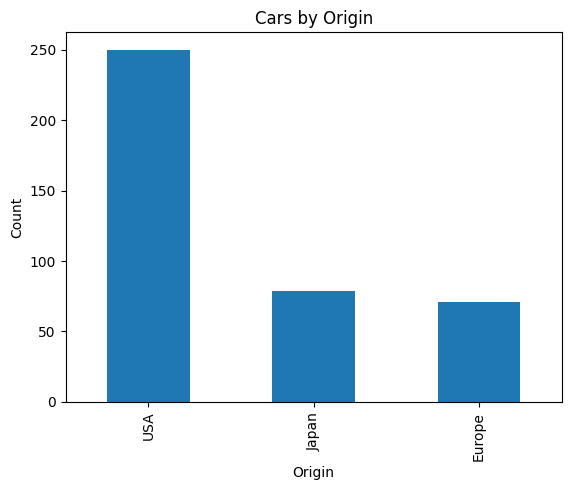

In [12]:
df["Origin"].value_counts().plot(kind="bar")

plt.title("Cars by Origin")
plt.xlabel("Origin")
plt.ylabel("Count")

plt.show()